In [7]:
import mlflow
from mlflow.tracking import MlflowClient
from typing import Any, Dict
import os
import sys
import torch
import pickle
from masters_dissertation_data_science.pipelines.training.model import (
    Generator1D, SingleCategoryDataset
)
from datetime import datetime
import pandas as pd
import numpy as np

def debug(msg: str) -> None:
    """Log messages with timestamp."""
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")

current_dir = os.getcwd()
root_dir = os.path.dirname(current_dir)

mlflow.set_tracking_uri(
    "sqlite:///C:/Users/tmdp1/masters-dissertation-data-science/mlruns.db"
)

client = MlflowClient()

experiment = client.get_experiment_by_name("masters_dissertation_data_science")

runs = client.search_runs(experiment_ids=[experiment.experiment_id])

for exp in client.search_experiments():
    print(exp.experiment_id, exp.name, exp.artifact_location)

1 masters_dissertation_data_science file:C:/Users/tmdp1/masters-dissertation-data-science/mlruns/1
0 Default file:C:/Users/tmdp1/masters-dissertation-data-science/mlruns/0


In [ ]:
OUTPUT_BASE_DIR = "../data/07_model_output"
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)

latent_dim = catalog.load("params:inference.latent_dim")
seq_len = catalog.load("params:inference.seq_len")
feature_dim = catalog.load("params:inference.feature_dim")
device = catalog.load("params:inference.device")
target_length = catalog.load("params:inference.target_length")

df_splitted = catalog.load("training.df_splitted")
ts_dict = catalog.load("training.time_series_folder")

num_samples = 100
chunks_per_sample = target_length // seq_len

for run in runs:
    run_name = run.data.tags.get("mlflow.runName", "default_run")
    tmp = run_name.split("_")
    domain = tmp[0]
    anomaly = tmp[1]
    
    train_dataset = SingleCategoryDataset(
        df=df_splitted,
        time_series_dict=ts_dict, 
        domain=domain,
        anomaly=anomaly,
        seq_len=seq_len,
        splits=["train", "val"]
    )
    train_mean = train_dataset.mean
    train_std = train_dataset.std
    
    model_path = client.download_artifacts(
        run_id=run.info.run_id,
        path="models/weights_trained_model.pt",
    )
    
    generator = Generator1D(
        latent_dim=latent_dim,
        seq_len=seq_len,
        feature_dim=feature_dim
    ).to(device)
    
    with open(model_path, "rb") as f:
        weights = pickle.load(f)
    
    generator.load_state_dict(weights["G_state_dict"])
    generator.eval()
    
    all_samples = []
    with torch.no_grad():
        for _ in range(num_samples):
            z = torch.randn(chunks_per_sample, latent_dim, device=device)
            synthetic_chunks = generator(z).cpu().numpy()
            
            chunks_reordered = synthetic_chunks.transpose(1, 0, 2)
            full_series = chunks_reordered.reshape(feature_dim, target_length)
            final_series = full_series.transpose(1, 0)
            
            all_samples.append(final_series)
    
    np_data = np.array(all_samples)
    np_data_denormalized = (np_data * train_std) + train_mean
    
    save_path = os.path.join(OUTPUT_BASE_DIR, f"synthetic_data_{run_name}.npy")
    np.save(save_path, np_data_denormalized)

[09/23/26 00:46:29] INFO     Loading data from params:inference.latent_dim (MemoryDataset)...  ]8;id=10731470;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731471;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from params:inference.seq_len (MemoryDataset)...     ]8;id=10731476;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731477;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from params:inference.feature_dim (MemoryDataset)... ]8;id=10731482;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731483;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from params:inference.device (MemoryDataset)...      ]8;id=10731488;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731489;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from params:inference.target_length                  ]8;id=10731494;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731495;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\
                             (MemoryDataset)...                                                                    

                    INFO     Loading data from training.df_splitted (CSVDataset)...            ]8;id=10731500;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731501;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from training.time_series_folder                     ]8;id=10731506;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10731507;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\
                             (PartitionedDataset)...                                                               

In [9]:
BASE_PATH = "../data/07_model_output"
ts_list = [file for file in os.listdir(BASE_PATH) if file.endswith(".npy")]
ts_list = [os.path.join(BASE_PATH, file) for file in ts_list]
debug(f"Total time series: {len(ts_list)}")

for ts in ts_list:
    data = np.load(ts)
    shape = data.shape
    if shape[0] != 100:
        debug("It was not generated 100 time series.")
    if shape[1] != 37100:
        debug("It was not generated time series with 37100 points.")
    if shape[2] != 3:
        debug("There is not three axis.")

[2026-09-23 00:47:32] Total time series: 42


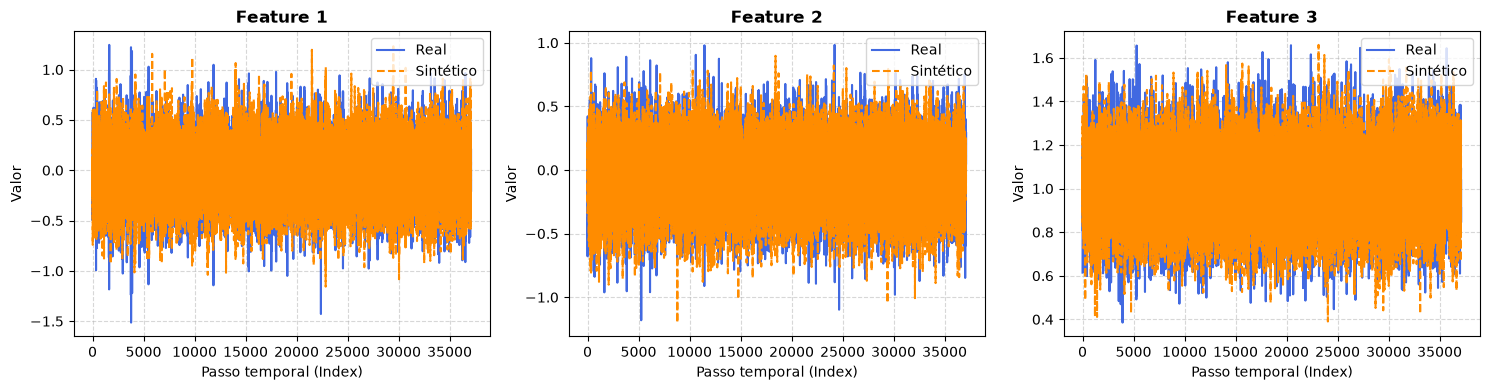

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# normal spd1000
real_ts = pd.read_parquet("../data/03_primary/time_series_data/test/ism330dhcx_acc_20240423_10_24_07_DataLog_0.parquet")
real_data = real_ts.values[1:,1:]
syn_data = np.load("../data/07_model_output/synthetic_data_spd1000_normal.npy")[0]

feature_names = ["Feature 1", "Feature 2", "Feature 3"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, ax in enumerate(axes):
    real_vals = real_data[:, i]
    syn_vals = syn_data[:, i]

    ax.plot(real_vals, label="Real", color="royalblue", linewidth=1.5)
    ax.plot(
        syn_vals,
        label="Sintético",
        color="darkorange",
        linewidth=1.5,
        linestyle="--",
    )

    ax.set_title(feature_names[i], fontsize=12, fontweight="bold")
    ax.set_xlabel("Passo temporal (Index)")
    ax.set_ylabel("Valor")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle
import pandas as pd

model_sizes = []

for run in runs:
    run_name = run.data.tags.get("mlflow.runName", "default_run")
    
    model_path = client.download_artifacts(
        run_id=run.info.run_id,
        path="models/weights_trained_model.pt",
    )
    
    file_size_bytes = os.path.getsize(model_path)
    file_size_kb = file_size_bytes / 1024

    with open(model_path, "rb") as f:
        weights = pickle.load(f)
        
    generator = Generator1D(
        latent_dim=latent_dim,
        seq_len=seq_len,
        feature_dim=feature_dim
    )
    generator.load_state_dict(weights["G_state_dict"])

    total_params = sum(p.numel() for p in generator.parameters())
    trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
    
    memory_params_kb = (total_params * 4) / 1024

    model_sizes.append({
        "run_name": run_name,
        "run_id": run.info.run_id,
        "file_size_kb": round(file_size_kb, 2),
        "total_params": f"{total_params:,}",
        "trainable_params": f"{trainable_params:,}",
        "memory_params_kb": round(memory_params_kb, 2),
    })

df_sizes = pd.DataFrame(model_sizes)
print(df_sizes.to_string(index=False))
print("Total file sizes (kb):", round(df_sizes.file_size_kb.sum(), 2))
print("Total minimum memory size (kb):", round(df_sizes.memory_params_kb.sum(), 2))

        run_name                           run_id  file_size_kb total_params trainable_params  memory_params_kb
  spd3000_normal 32bd4d9a89d04273935beaf24231e470        396.54       90,211           90,211            352.39
  spd2800_normal 7073b4ebf63446afb90344bc6a6fecfb        396.54       90,211           90,211            352.39
  spd2400_normal 0cb59964e8d244ce906f9bb65d5cd401        396.54       90,211           90,211            352.39
  spd2000_normal 4f811357f59c4207b6a9d066d3d63cb6        396.54       90,211           90,211            352.39
  spd1900_normal fbd7fab53daf48b5a6772e21a677d57b        396.54       90,211           90,211            352.39
  spd1800_normal 4dae9783d16b479b8a3a8fd1a1a64742        396.54       90,211           90,211            352.39
  spd1700_normal 2a41c9748df94fc19977775f0e8e3026        396.54       90,211           90,211            352.39
  spd1600_normal 4f285002694d4bef8605f37b1fc5f726        396.54       90,211           90,211           